In [1]:
# ---------------------------------------------------------
# 1. PDF Source Configuration
# ---------------------------------------------------------

import os, sys, time, warnings, logging
import fitz, cv2
import numpy as np

PDF_REL_PATH = "data/raw/vie/an-nam-chi-nguyen/HVB_002_PDFScan_Viet_An Nam Chí Nguyên.pdf"
WORK_ID      = "HVB_002"
WORK_TITLE   = "An Nam Chí Nguyên"

START_PAGE   = 11   # INDEX
NUM_PAGES    = 1   # OFFSET (None for all)
USE_LLM      = True # LLM for corrector
# ---------------------------------------------------------

# Tự động kết nối đường dẫn tới các helper trong src/run_ocr/vie
current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
src_ocr_path = os.path.abspath(os.path.join(current_dir, "..", "src", "run_ocr", "vie"))
if src_ocr_path not in sys.path:
    sys.path.insert(0, src_ocr_path)

from ocr_utils import (
    find_file, init_paddleocr, init_vietocr,
    run_ocr_page, smart_sort_layout
)
from llm_corrector import correct_text_with_llm

print("✅ Đã import thành công & sẵn sàng cấu hình pipeline!")

✅ Đã import thành công & sẵn sàng cấu hình pipeline!


In [2]:
# ---------------------------------------------------------
# 2. LOAD & RENDER PDF TO IMAGES
# ---------------------------------------------------------

pdf_path = os.path.abspath(os.path.join(current_dir, "..", PDF_REL_PATH))
if not os.path.exists(pdf_path):
    pdf_path = find_file(PDF_REL_PATH, WORK_ID)

if not pdf_path or not os.path.exists(pdf_path):
    raise FileNotFoundError(f"❌ Không tìm thấy file PDF tại: {PDF_REL_PATH}")

print(f"📂 Đang mở file PDF: {os.path.basename(pdf_path)}")
doc = fitz.open(pdf_path)
total_pages = len(doc)

end_page = min(START_PAGE + NUM_PAGES, total_pages) if NUM_PAGES else total_pages
print(f"📑 Sẽ chạy từ trang {START_PAGE + 1} đến trang {end_page} (Tổng: {end_page - START_PAGE} trang)...")

pages_images = []
for i in range(START_PAGE, end_page):
    page = doc[i]
    mat = fitz.Matrix(300 / 72, 300 / 72)
    pix = page.get_pixmap(matrix=mat)
    
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)
    img = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR if pix.n == 4 else cv2.COLOR_RGB2BGR)
    pages_images.append(img)

doc.close()
print(f"✅ Đã render xong {len(pages_images)} trang ảnh!")

📂 Đang mở file PDF: HVB_002_PDFScan_Viet_An Nam Chí Nguyên.pdf
📑 Sẽ chạy từ trang 12 đến trang 12 (Tổng: 1 trang)...
✅ Đã render xong 1 trang ảnh!


In [3]:
# ---------------------------------------------------------
# 3. KHỞI TẠO ENGINE OCR (PADDLE + VIETOCR)
# ---------------------------------------------------------

print("⏳ Khởi tạo PaddleOCR (Detector)...", end=" ", flush=True)
paddle_engine = init_paddleocr(lang="vi")
print("OK")

print("⏳ Khởi tạo VietOCR (Recognizer)...", end=" ", flush=True)
vietocr_engine = init_vietocr()
print("OK ✅")


⏳ Khởi tạo PaddleOCR (Detector)... 

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\James\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\James\.paddlex\official_models\UVDoc`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\James\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\James\.paddlex\official_models\PP-OCRv6_medium_rec`.


OK
⏳ Khởi tạo VietOCR (Recognizer)...   → Khởi tạo VietOCR (vgg_transformer): d:\HCMUS\HP2\MTH020-NLP\nlp-k35-midterm\src\run_ocr\vie\weights\vgg_transformer.pth
OK ✅


In [4]:
# ---------------------------------------------------------
# 4. PIPELINE OCR + LLM CORRECTION
# ---------------------------------------------------------

result_pages = []
total_t0 = time.time()

print(f"\n🚀 Bắt đầu xử lý {len(pages_images)} trang...")
for idx, img in enumerate(pages_images):
    t0 = time.time()
    print(f"  → [Trang {idx + 1}/{len(pages_images)}] Đang nhận diện...", end=" ", flush=True)
    
    # 1. Paddle detect box → crop → VietOCR đọc text
    ocr_lines = run_ocr_page(img, paddle_engine, vietocr_engine)
    
    # 2. Sắp xếp layout chuẩn từ trên xuống dưới, trái qua phải
    page_text = smart_sort_layout(ocr_lines)

elapsed_total = time.time() - total_t0
print(f"\n🎉 HOÀN TẤT PIPELINE! Tổng thời gian: {elapsed_total:.2f} giây (~{elapsed_total/len(pages_images):.1f}s/trang).")



🚀 Bắt đầu xử lý 1 trang...
  → [Trang 1/1] Đang nhận diện... 
🎉 HOÀN TẤT PIPELINE! Tổng thời gian: 98.68 giây (~98.7s/trang).


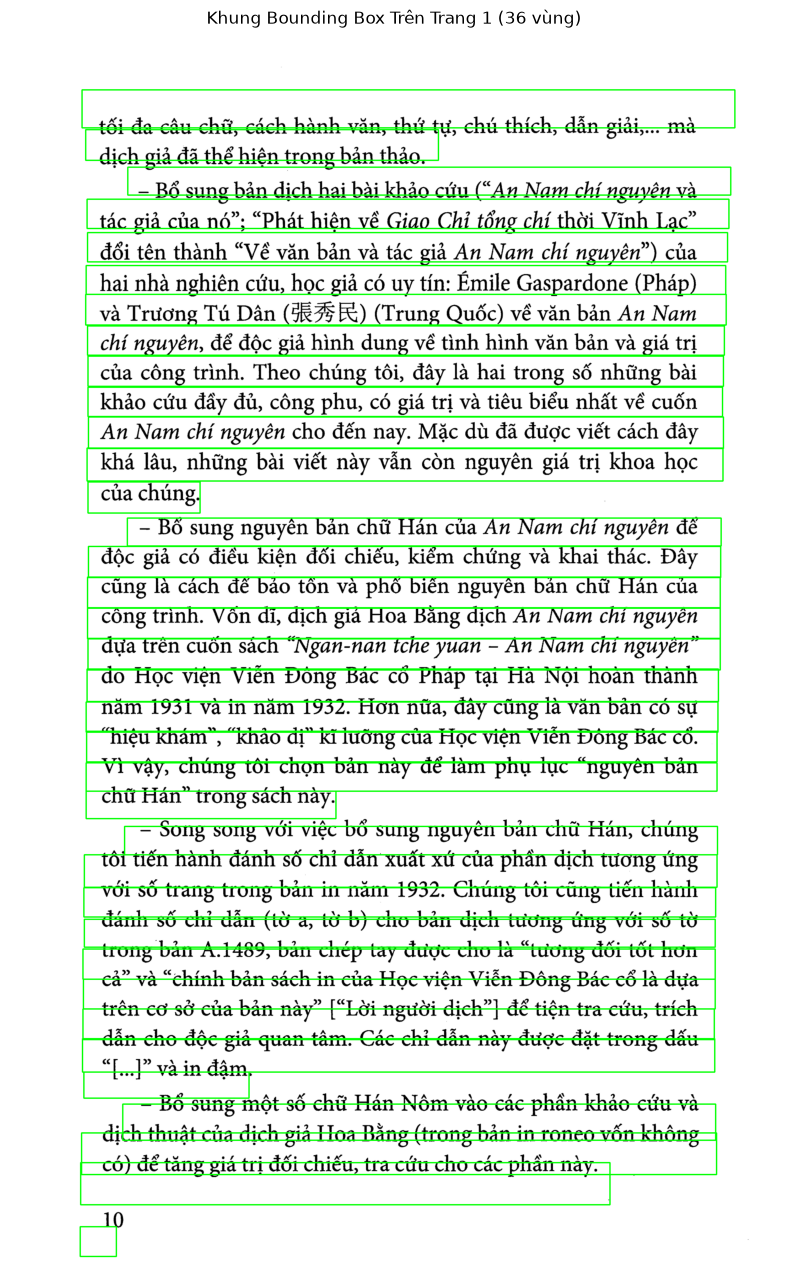

In [5]:
import matplotlib.pyplot as plt
def draw_ocr_boxes(image, ocr_lines):
    """Vẽ bounding box màu xanh lá lên ảnh."""
    img_drawn = image.copy()
    for line in ocr_lines:
        box = np.array(line[0]).astype(np.int32).reshape((-1, 1, 2))
        cv2.polylines(img_drawn, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    return img_drawn

img_with_boxes = draw_ocr_boxes(img, ocr_lines)

# Hiển thị bounding box trong mode Interactive:
plt.figure(figsize=(12, 16))
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title(f"Khung Bounding Box Trên Trang 1 ({len(ocr_lines)} vùng)")
plt.axis("off")
plt.show()

In [6]:
print("\n--- All Lines ---")
for idx, line in enumerate(ocr_lines):
    box, (text, score) = line
    print(f"{idx+1:2d}. [{score*100:5.1f}%] : {text}")


--- All Lines ---
 1. [ 63.5%] : thi da conchiếc chính cần thị trích thích dân chính mạnh
 2. [ 82.1%] : dịch ai đã thế hiện trong bản thật
 3. [ 88.5%] : Bổ sung hản dịch hai bài khảo cứu (?An Nam chí nguyên và
 4. [ 89.0%] : tác giả của nóm: ?Phát hiện về Giao Chỉ tổng chí thời Vĩnh Lạc?
 5. [ 91.9%] : đổi tên thành ?Về văn bản và tác giả An Nam chí nguyên?) của
 6. [ 93.2%] : hai nhà nghiên cứu, học giả có uy tín: Emile Gaspardone (Pháp)
 7. [ 89.1%] : và Trương Tú Dân (K?R) (Trung Quốc) về văn bản An Nam
 8. [ 93.0%] : chí nguyên, để độc giả hình dung về tình hình văn bản và giá trị
 9. [ 92.3%] : của công trình. Theo chúng tôi, đây là hai trong số những bài
10. [ 93.3%] : khảo cứu đầy đủ, công phu, có giá trị và tiêu biểu nhất về cuốn
11. [ 92.3%] : An Nam chí nguyên cho đến nay. Mặc dù đã được viết cách đây
12. [ 93.5%] : khá lâu, những bài viết này vẫn còn nguyên giá trị khoa học
13. [ 93.6%] : của chúng
14. [ 88.5%] : - Bổ sung nguyên bản chữ hán của An Nam chí nguyên đế
15. [

In [7]:
print(page_text)

thi da conchiếc chính cần thị trích thích dân chính mạnh
dịch ai đã thế hiện trong bản thật
Bổ sung hản dịch hai bài khảo cứu (?An Nam chí nguyên và
tác giả của nóm: ?Phát hiện về Giao Chỉ tổng chí thời Vĩnh Lạc?
đổi tên thành ?Về văn bản và tác giả An Nam chí nguyên?) của
hai nhà nghiên cứu, học giả có uy tín: Emile Gaspardone (Pháp)
và Trương Tú Dân (K?R) (Trung Quốc) về văn bản An Nam
chí nguyên, để độc giả hình dung về tình hình văn bản và giá trị
của công trình. Theo chúng tôi, đây là hai trong số những bài
khảo cứu đầy đủ, công phu, có giá trị và tiêu biểu nhất về cuốn
An Nam chí nguyên cho đến nay. Mặc dù đã được viết cách đây
khá lâu, những bài viết này vẫn còn nguyên giá trị khoa học
của chúng
- Bổ sung nguyên bản chữ hán của An Nam chí nguyên đế
độc giả có điều kiện đối chiếu, kiểm chứng và khai thác. Đây
cũng là cách để bảo tồn và phổ biến nguyên bản chữ Hán của
công trình. Vốn di, dịch giả Hoa Bằng dịch An Nam chí nguyên
dựa trên cuốn sách ngan-nan tche yuan - An Nam chi ng

In [ ]:
# 4. Hậu xử lý LLM sửa lỗi OCR (nếu USE_LLM = True)
if USE_LLM:
    try:
        llm_text = correct_text_with_llm(page_text, work_title=WORK_TITLE, language="vie")
        print(f"Xong ({time.time() - t0:.1f}s) - {len(ocr_lines)} dòng.")
        print(llm_text)
    except Exception as e:
        print(f"(LLM lỗi: {e}, dùng text Raw OCR)", end=" ")

  LLM chunk 1/1 (36 dòng)... 

In [ ]:
# # ---------------------------------------------------------
# # 4. EXPORT TEXT TO .TXT
# # ---------------------------------------------------------

# output_dir = os.path.abspath(os.path.join(current_dir, "..", "data", "ocr_output"))
# os.makedirs(output_dir, exist_ok=True)

# out_file = os.path.join(output_dir, f"{WORK_ID}_test_vie_raw.txt")
# final_full_text = clean_viet_text("\n\n".join(result_pages))

# with open(out_file, "w", encoding="utf-8") as f:
#     f.write(final_full_text)

# print(f"💾 Đã lưu kết quả hoàn chỉnh vào:\n  👉 {out_file}\n")
# print("-" * 50)
# print("📋 PREVIEW 1000 KÝ TỰ ĐẦU TIÊN:")
# print("-" * 50)
# print(final_full_text[:1000])
